# Carving vs the cube method: how different are they, really?

Both [`datacarve`](https://github.com/bbonik/datacarve) and **balanced
sampling via the cube method** (Deville & Tillé 2004) select a fixed-size
subset that satisfies balance requirements across several attributes. So what
actually differs? This notebook measures it, head to head, on the same data
with the same targets.

The short version of how each works:

- **datacarve** solves an integer program: it *optimizes* the choice of rows so
  the subset's histograms match the targets as closely as the pool allows.
  Deterministic, exact, no randomness.
- **The cube method** draws a *random* sample in which every row has a known,
  pre-declared inclusion probability, while steering the randomness so the
  balance constraints come out (approximately) satisfied. Randomness is the
  whole point: it makes the sample unbiased with respect to **every** attribute
  — including ones you never measured.

To expose that difference, the data below contains a **hidden attribute**
(`screen_time`) that is correlated with the visible ones but is *given to
neither method*. We then check how each method's subsets behave on it.

Setup: a synthetic survey panel (same as the [quota sampling
notebook](survey_quota_sampling.ipynb)), fully offline and seeded.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from datacarve import undersample_dataset

plt.style.use("ggplot")
rng = np.random.default_rng(7)

N, K = 6_000, 1_500

age = np.clip(20 + np.abs(rng.normal(5, 14, N)), 18, 80)      # skews young
gender = rng.choice([0.0, 1.0], N, p=[0.62, 0.38])            # 0=M, 1=F
region = rng.choice([0.0, 1.0, 2.0], N, p=[0.65, 0.25, 0.10]) # urban/sub/rural

# HIDDEN attribute: depends on age and region; NOT given to either method
screen_time = 10 - 0.08 * age + 1.5 * (region == 0.0) + rng.normal(0, 1.0, N)

# shared targets: gender 50/50, region 45/35/20
t_female = 0.5 * K
t_region = np.array([0.45, 0.35, 0.20]) * K
print(f"pool: {N:,} rows | subset size: {K:,}")
print(f"targets: female {t_female:.0f}, regions {t_region}")

pool: 6,000 rows | subset size: 1,500
targets: female 750, regions [675. 525. 300.]


## 1. The cube method, implemented

There is no established Python package, so here is a compact implementation
(flight phase + landing phase). Inclusion probabilities are set per
(gender × region) cell so that *expected* counts hit the targets; the flight
phase then steers the randomness to keep the realized counts close to those
expectations, fixing one row's fate (in or out) per step.


In [2]:
def inclusion_probs():
    """Cell-constant inclusion probabilities hitting the targets in expectation."""
    pi = np.zeros(N)
    shares_g = {0: 0.5, 1: 0.5}
    shares_r = {0: 0.45, 1: 0.35, 2: 0.20}
    for g in (0, 1):
        for r in (0, 1, 2):
            cell = (gender == g) & (region == r)
            target = shares_g[g] * shares_r[r] * K
            pi[cell] = min(target / cell.sum(), 1.0)
    return pi


def cube_sample(pi0, X, rng):
    """Cube method: fast flight phase + simple landing.

    X: (N, p) balancing variables. Keeps a working set of p+1 undecided
    rows; each step moves their probabilities along a direction that
    preserves the balance equations, until one hits 0 or 1.
    """
    eps = 1e-9
    pi = pi0.copy()
    A = X / pi0[:, None]                      # a_i = x_i / pi_i(0)
    p = X.shape[1]

    queue = np.where((pi > eps) & (pi < 1 - eps))[0]
    ptr, active = 0, []

    while True:
        while len(active) < p + 1 and ptr < len(queue):
            active.append(int(queue[ptr])); ptr += 1
        if len(active) <= p:
            break                             # flight phase done

        B = A[active].T                       # (p, p+1)
        u = np.linalg.svd(B)[2][-1]           # ~null vector of B
        pis = pi[active]
        big = 1e18
        with np.errstate(divide="ignore", invalid="ignore"):
            lam1 = np.min(np.where(u > 1e-12, (1 - pis) / u,
                          np.where(u < -1e-12, -pis / u, big)))
            lam2 = np.min(np.where(u > 1e-12, pis / u,
                          np.where(u < -1e-12, (pis - 1) / u, big)))
        if rng.random() < lam2 / (lam1 + lam2):
            pi[active] = pis + lam1 * u       # E[pi] is preserved
        else:
            pi[active] = pis - lam2 * u
        pi[active] = np.clip(pi[active], 0.0, 1.0)
        active = [i for i in active if eps < pi[i] < 1 - eps]

    if active:                                # landing: <= p fractional rows
        frac_pi = pi[active]
        k = int(round(frac_pi.sum()))
        pi[active] = 0.0
        if k > 0:
            chosen = rng.choice(active, size=k, replace=False,
                                p=frac_pi / frac_pi.sum())
            pi[chosen] = 1.0
    return pi > 0.5


pi0 = inclusion_probs()
X_bal = np.column_stack([
    (gender == 1).astype(float),      # female count
    (region == 0).astype(float),      # urban count
    (region == 1).astype(float),      # suburban count
    pi0,                              # fixed sample size
])
print("sum of inclusion probabilities:", pi0.sum())  # = K

sum of inclusion probabilities: 1500.0


## 2. Same targets, both methods: how exactly do they land?


In [3]:
# --- datacarve: one deterministic carve
data = np.column_stack([gender, region])
carve_mask = undersample_dataset(
    data, data_to_keep=K,
    target_distribution=["uniform", [45, 35, 20]],
    categorical_dims=[0, 1],
    verbose=False, scatterplot_matrix=False,
)

# --- cube: 200 random draws
R = 200
cube_counts = np.zeros((R, 4))     # female, urban, suburban, rural
cube_masks = []
for i in range(R):
    m = cube_sample(pi0, X_bal, rng)
    cube_masks.append(m)
    cube_counts[i] = [(gender[m] == 1).sum(), (region[m] == 0).sum(),
                      (region[m] == 1).sum(), (region[m] == 2).sum()]

def count_row(mask):
    return [(gender[mask] == 1).sum(), (region[mask] == 0).sum(),
            (region[mask] == 1).sum(), (region[mask] == 2).sum()]

print(f"{'':12s}  female   urban  suburb   rural")
print(f"{'target':12s}  {t_female:6.0f}  {t_region[0]:6.0f}  {t_region[1]:6.0f}  {t_region[2]:6.0f}")
print(f"{'datacarve':12s}  " + "  ".join(f"{c:6d}" for c in count_row(carve_mask)))
print(f"{'cube (mean)':12s}  " + "  ".join(f"{c:6.1f}" for c in cube_counts.mean(0)))
print(f"{'cube (std)':12s}  " + "  ".join(f"{c:6.1f}" for c in cube_counts.std(0)))
print(f"{'cube (worst)':12s}  " + "  ".join(
    f"{c:6.0f}" for c in np.abs(cube_counts - [t_female, *t_region]).max(0)))

              female   urban  suburb   rural
target           750     675     525     300
datacarve        750     675     525     300
cube (mean)    750.2   674.9   525.2   299.9
cube (std)       6.0     1.6     3.7     2.4
cube (worst)      14       4      10       7


First difference, visible already: **datacarve hits the targets exactly, every
time; the cube method hits them in expectation**, with each draw wandering a
few rows around the target (and a rare draw missing by more). If your
datasheet says "exactly 750/750", only one of these delivers it per draw.

## 3. The hidden attribute: where randomness earns its keep

Neither method saw `screen_time`. We now look at the mean screen time of
**urban women** in each subset — a subgroup whose composition neither method
constrained *internally* — and compare it against the pool truth for urban
women. Repeating cube's random draw traces out its sampling distribution. For
datacarve, we rerun the carve on randomly shuffled row orders: the optimum is
degenerate (many subsets are equally optimal), so shuffling changes which one
the solver happens to return.


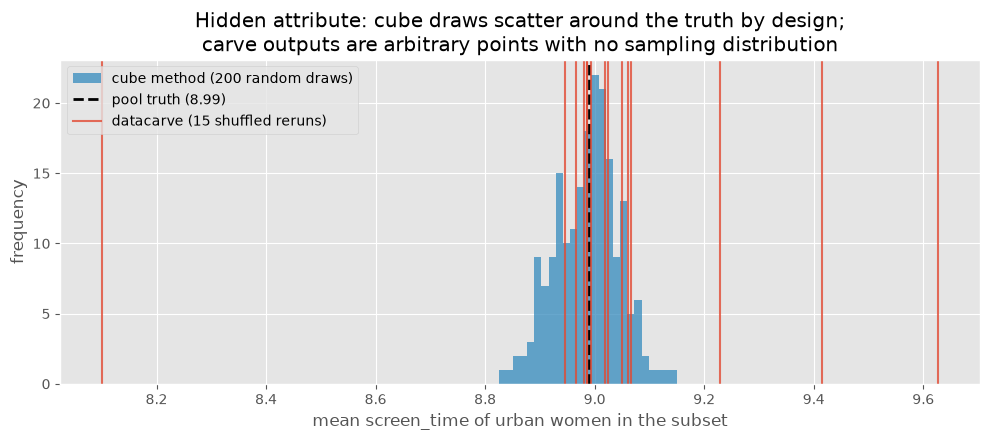

pool truth:            8.990
cube:      mean 8.987, std 0.058 (centered on truth, spread = valid uncertainty)
datacarve: mean 9.030, std 0.309 (each value exact for its subset; no theory links spread to uncertainty)


In [4]:
pool_truth = screen_time[(gender == 1) & (region == 0)].mean()

# cube: sampling distribution over the 200 draws
cube_means = np.array([
    screen_time[m & (gender == 1) & (region == 0)].mean() for m in cube_masks
])

# datacarve: 15 reruns on shuffled row orders
carve_means = []
for s in range(15):
    perm = np.random.default_rng(s).permutation(N)
    m_p = undersample_dataset(
        data[perm], data_to_keep=K,
        target_distribution=["uniform", [45, 35, 20]],
        categorical_dims=[0, 1],
        verbose=False, scatterplot_matrix=False,
    )
    sel = perm[m_p]                       # map back to original rows
    sel_mask = np.zeros(N, dtype=bool); sel_mask[sel] = True
    carve_means.append(
        screen_time[sel_mask & (gender == 1) & (region == 0)].mean())
carve_means = np.array(carve_means)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(cube_means, bins=25, color="#348ABD", alpha=0.75,
        label=f"cube method ({R} random draws)")
ax.axvline(pool_truth, color="black", lw=2, ls="--",
           label=f"pool truth ({pool_truth:.2f})")
for i, v in enumerate(carve_means):
    ax.axvline(v, color="#E24A33", lw=1.5, alpha=0.8,
               label="datacarve (15 shuffled reruns)" if i == 0 else None)
ax.set_xlabel("mean screen_time of urban women in the subset")
ax.set_ylabel("frequency")
ax.set_title("Hidden attribute: cube draws scatter around the truth by design;\n"
             "carve outputs are arbitrary points with no sampling distribution")
ax.legend()
plt.tight_layout(); plt.show()

print(f"pool truth:            {pool_truth:.3f}")
print(f"cube:      mean {cube_means.mean():.3f}, std {cube_means.std():.3f} "
      f"(centered on truth, spread = valid uncertainty)")
print(f"datacarve: mean {carve_means.mean():.3f}, std {carve_means.std():.3f} "
      f"(each value exact for its subset; no theory links spread to uncertainty)")

Read the figure carefully, because the difference is subtle and this *is* the
answer to "how different are they really":

- The **blue histogram** is the cube method's sampling distribution. It is
  centered on the pool truth *by mathematical guarantee* — known inclusion
  probabilities make the estimator unbiased for every attribute, including
  hidden ones — and its spread is a *valid* uncertainty measure you can build
  confidence intervals from.
- The **red lines** are datacarve reruns — and in this experiment they scatter
  **several times wider** than cube's sampling distribution (std ≈ 0.31 vs
  ≈ 0.06 here), and are not centered on the truth by any guarantee. This is
  the degenerate optimum made visible: many subsets are equally optimal, the
  solver's tie-breaking picks one essentially by accident of input order, and
  the resulting hidden-attribute value wanders across a range that **no
  theory describes**. The single subset you'd actually use is *one* of those
  red lines, and nothing tells you which.

That is the practical content of "no valid confidence intervals": it's not
that carve values are always far from the truth — it's that their run-to-run
variation is larger than proper sampling noise *and* unquantifiable in
advance. Only one of the two methods comes with a guarantee about behavior on
attributes nobody measured.

## 4. What the cube method can't do: shape a distribution

The comparison so far played on cube's home turf (categorical quotas). Now the
reverse. Ask both methods for something datacarve considers routine: *make the
age distribution flat*, on top of the same gender/region targets.


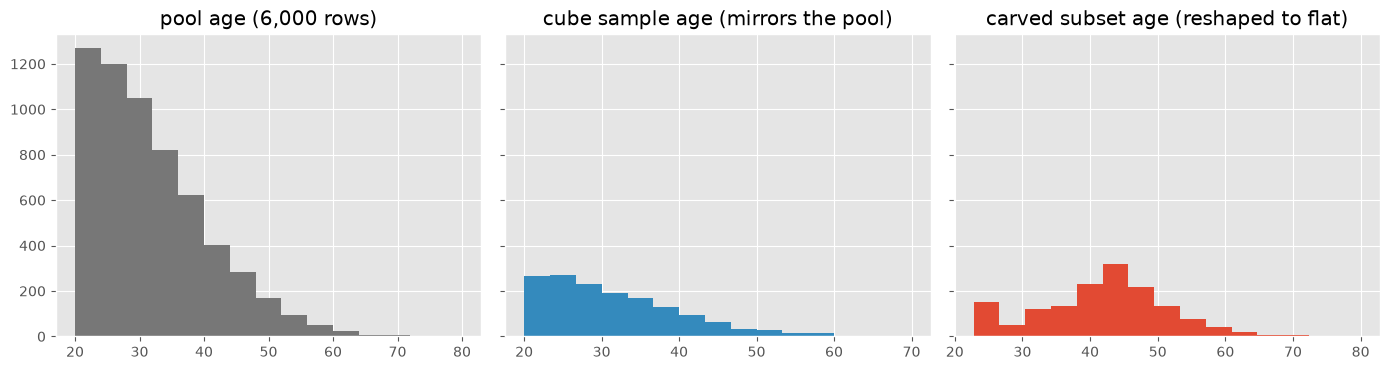

In [5]:
data3 = np.column_stack([age, gender, region])
carve3 = undersample_dataset(
    data3, data_to_keep=K,
    target_distribution=["uniform", "uniform", [45, 35, 20]],
    categorical_dims=[1, 2],
    verbose=False, scatterplot_matrix=False,
)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
axes[0].hist(age, bins=15, color="#777777")
axes[0].set_title(f"pool age ({N:,} rows)")
axes[1].hist(age[cube_masks[0]], bins=15, color="#348ABD")
axes[1].set_title("cube sample age (mirrors the pool)")
axes[2].hist(age[carve3], bins=15, color="#E24A33")
axes[2].set_title("carved subset age (reshaped to flat)")
plt.tight_layout(); plt.show()

The cube sample *mirrors* the pool's age skew — by design: it balances
**totals and means** of declared variables, not the *shape* of a
distribution. To make cube produce a flat age profile you would have to
engineer age-dependent inclusion probabilities yourself (a small
inverse-density estimation problem, before sampling even starts), and the
result would still hold only in expectation. In datacarve, reshaping —
uniform, gaussian, or any custom histogram, per attribute — is one argument.

## Verdict: different tools, different guarantees

| | datacarve (MILP) | cube method |
|---|---|---|
| Hits categorical quotas | **exactly, every run** | in expectation, ± a few rows per draw |
| Shapes continuous distributions | any target histogram, one argument | means/totals only; shaping needs hand-built inclusion probabilities |
| Hidden (unmeasured) attributes | roughly neutral in practice, **no guarantee** | **unbiased by design** |
| Uncertainty quantification | none (deterministic, degenerate optimum) | valid design-based CIs |
| Repeated runs | same or arbitrarily different subsets | honest sampling distribution |
| Tooling | `pip install datacarve` | R survey packages / roll your own |

So the two methods are *not* interchangeable, and neither dominates:

- Need an **exact, documented composition** — a shipped benchmark, a datasheet
  claim, a shaped stress-test distribution? **Carve.**
- Need **population estimates with confidence intervals**, robust to
  attributes nobody measured? **Cube** (or any probability design).
- Want most of both? The hybrid is natural: use the MILP to fix *how many*
  rows per joint cell, then draw *which* rows randomly within each cell —
  exact composition, plus randomness conditional on everything you
  constrained. This ships as datacarve's `randomize=` parameter — see the [hybrid randomized carving notebook](hybrid_randomized_carving.ipynb).

**Install:** `pip install datacarve` &nbsp;|&nbsp; **Repo:**
<https://github.com/bbonik/datacarve>

Reference: Deville, J.-C., & Tillé, Y. (2004). *Efficient balanced sampling:
the cube method.* Biometrika, 91(4), 893–912.
